In [1]:
import os
import optuna
import pandas as pd
import numpy as np
import scipy as sp
import seaborn as sns
import xgboost as xgb
from scipy import optimize
from scipy.interpolate import interp1d
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn import ensemble, metrics, neighbors, model_selection

In [2]:
def caluculate_eer(y_true, y_score):
    fpr, tpr, thresholds = metrics.roc_curve(y_true, y_score, pos_label=1)

    eer = optimize.brentq(lambda x : 1. - x - interp1d(fpr, tpr)(x), 0., 1.)

    thresh = interp1d(fpr, thresholds)(eer)

    return eer, thresh

In [3]:
# scaler

scaler_orig = StandardScaler()
scaler_norm = StandardScaler()
scaler_sec = StandardScaler()
scaler_rerec = StandardScaler()

In [4]:
training_df = pd.read_csv('data2/for-original_train.csv').dropna(axis=0)
testing_df = pd.read_csv('data2/for-original_test.csv').dropna(axis=0)
validation_df = pd.read_csv('data2/for-original_validation.csv').dropna(axis=0)

X_train = training_df.drop(['Unnamed: 0','filename', 'label', 'duration'], axis=1).dropna(axis=0)
X_test = testing_df.drop(['Unnamed: 0','filename', 'label', 'duration'], axis=1).dropna(axis=0)
X_valid = validation_df.drop(['Unnamed: 0','filename', 'label', 'duration'], axis=1).dropna(axis=0)

X_train_valid = pd.concat([X_train, X_valid], ignore_index=False)

y_train = training_df['label']
y_test = testing_df['label']
y_valid = validation_df['label']

y_train_valid = pd.concat([y_train, y_valid], ignore_index=False)

scaler_orig.fit(X_train)

X_train_scaled = scaler_orig.transform(X_train)
X_valid_scaled = scaler_orig.transform(X_valid)
X_test_scaled = scaler_orig.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_valid_scaled   = pd.DataFrame(X_valid_scaled, columns=X_valid.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled, columns=X_test.columns)

FileNotFoundError: [Errno 2] No such file or directory: 'data2/for-original_train.csv'

In [ ]:
norm_training_df = pd.read_csv('data2/for-norm_train.csv').dropna(axis=0)
norm_testing_df = pd.read_csv('data2/for-norm_test.csv').dropna(axis=0)
norm_validation_df = pd.read_csv('data2/for-norm_validation.csv').dropna(axis=0)

X_norm_training = norm_training_df.drop(['Unnamed: 0', 'filename', 'duration', 'label'], axis=1)
X_norm_testing = norm_testing_df.drop(['Unnamed: 0', 'filename', 'duration', 'label'], axis=1)
X_norm_validation = norm_validation_df.drop(['Unnamed: 0', 'filename', 'duration', 'label'], axis=1)

X_norm_train_valid = pd.concat([X_norm_training, X_norm_validation], ignore_index=False)


y_norm_training = norm_training_df['label']
y_norm_testing = norm_testing_df['label']
y_norm_validation = norm_validation_df['label']

y_norm_train_valid = pd.concat([y_norm_training, y_norm_validation], ignore_index=False)

scaler_norm.fit(X_norm_training)

X_norm_training_scaled = scaler_norm.transform(X_norm_training)
X_norm_valid_scaled = scaler_norm.transform(X_norm_validation)
X_norm_test_scaled = scaler_norm.transform(X_norm_testing)

X_norm_training_scaled = pd.DataFrame(X_norm_training_scaled, columns=X_norm_training.columns)
X_norm_valid_scaled  = pd.DataFrame(X_norm_valid_scaled, columns=X_norm_validation.columns)
X_norm_test_scaled  = pd.DataFrame(X_norm_test_scaled, columns=X_norm_testing.columns)


In [ ]:
sec_train = pd.read_csv('data2/for-2sec_train.csv').dropna(axis=0)
sec_test = pd.read_csv('data2/for-2sec_test.csv').dropna(axis=0)
sec_valid = pd.read_csv('data2/for-2sec_validation.csv').dropna(axis=0)

X_sec_train = sec_train.drop(['Unnamed: 0', 'filename', 'duration', 'label'], axis=1)
X_sec_test = sec_test.drop(['Unnamed: 0', 'filename', 'duration', 'label'], axis=1)
X_sec_valid = sec_valid.drop(['Unnamed: 0', 'filename', 'duration', 'label'], axis=1)

X_sec_train_valid = pd.concat([X_sec_train, X_sec_valid], ignore_index=False)

y_sec_train = sec_train['label']
y_sec_test = sec_test['label']
y_sec_valid = sec_valid['label']

y_sec_train_valid = pd.concat([y_sec_train, y_sec_valid], ignore_index=False)

scaler_sec.fit(X_sec_train)

X_sec_train_scaled = scaler_sec.transform(X_sec_train)
X_sec_valid_scaled = scaler_sec.transform(X_sec_valid)
X_sec_test_scaled = scaler_sec.transform(X_sec_test)

X_sec_train_scaled = pd.DataFrame(X_sec_train_scaled, columns=X_sec_train.columns)
X_sec_valid_scaled   = pd.DataFrame(X_sec_valid_scaled, columns=X_sec_valid.columns)
X_sec_test_scaled  = pd.DataFrame(X_sec_test_scaled, columns=X_sec_test.columns)

In [ ]:
rerec_train_df = pd.read_csv('data2/for-rerec_train.csv').dropna(axis=0)
rerec_test_df = pd.read_csv('data2/for-rerec_test.csv').dropna(axis=0)
rerec_valid_df = pd.read_csv('data2/for-rerec_validation.csv').dropna(axis=0)

X_rerec_train = rerec_train_df.drop(['Unnamed: 0', 'duration', 'filename', 'label'], axis=1)
X_rerec_test = rerec_test_df.drop(['Unnamed: 0', 'duration', 'filename', 'label'], axis=1)
X_rerec_valid = rerec_valid_df.drop(['Unnamed: 0', 'duration', 'filename', 'label'], axis=1)

X_rerec_train_valid = pd.concat([X_rerec_train, X_rerec_valid], ignore_index=False)

y_rerec_train = rerec_train_df['label']
y_rerec_test = rerec_test_df['label']
y_rerec_valid = rerec_valid_df['label']

y_rerec_train_valid = pd.concat([y_rerec_train, y_rerec_valid], ignore_index=False)

scaler_rerec.fit(X_rerec_train)

X_rerec_train_scaled = scaler_rerec.transform(X_rerec_train)
X_rerec_valid_scaled = scaler_rerec.transform(X_rerec_valid)
X_rerec_test_scaled = scaler_rerec.transform(X_rerec_test)

X_rerec_train_scaled = pd.DataFrame(X_rerec_train_scaled, columns=X_rerec_train.columns)
X_rerec_valid_scaled   = pd.DataFrame(X_rerec_valid_scaled, columns=X_rerec_valid.columns)
X_rerec_test_scaled  = pd.DataFrame(X_rerec_test_scaled, columns=X_rerec_test.columns)

In [ ]:
datasets = {
    "original":(X_train_scaled, X_valid_scaled, y_train, y_valid),
    "norm":(X_norm_training_scaled, X_norm_valid_scaled,  y_norm_training, y_norm_validation),
    "sec":(X_sec_train_scaled, X_sec_valid_scaled, y_sec_train, y_sec_valid),
    "rerec":(X_rerec_train_scaled, X_rerec_valid_scaled,  y_rerec_train, y_rerec_valid),
}

In [23]:
# Оптимизация гиперпараметров RF-моделей со всеми признаками
def create_objective(X_tr, X_valid, y_tr, y_valid):

    def objective(trial):
        n_estimators = trial.suggest_int('n_estimators', 100, 300)
        max_depth = trial.suggest_int('max_depth', 3, 8)
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 10, 50)

        clf = ensemble.RandomForestClassifier(
            n_estimators=n_estimators,
            criterion='entropy',
            max_depth=max_depth,
            max_features='sqrt',
            min_samples_leaf=min_samples_leaf,
            n_jobs=-1
        )
        clf.fit(X_tr, y_tr)

        y_score = clf.predict_proba(X_valid)[:, 1]

        eer, best_threshold = caluculate_eer(y_valid, y_score)

        trial.set_user_attr("eer_threshold", float(best_threshold))

        trial.set_user_attr("accuracy", metrics.accuracy_score(y_valid, y_score > 0.5))


        # y_pred_test = clf.predict(X_test)
        
        # score = metrics.accuracy_score(y_test, y_pred_test)

        return eer
    return objective



In [38]:
db_url = "sqlite:///RF_full3.db"
for name, (X_tr, X_valid, y_tr, y_valid) in datasets.items():
    print(f"\n>>> Запуск оптимизации для датасета: {name}")

    # уникальное имя исследования
    study_name = f"rf_{name}"

    try:
        optuna.delete_study(study_name=study_name, storage=db_url)
    except KeyError:
        pass

    study = optuna.create_study(
        study_name=study_name,
        direction="minimize",
        storage=db_url,
        load_if_exists=True,
        
    )

    obj_func = create_objective(X_tr, X_valid, y_tr, y_valid)

    study.optimize(obj_func, n_trials=100, n_jobs=1)

    print(f"Лучшие параметры для {name}: {study.best_params} с показателем EER: {study.best_value}")


>>> Запуск оптимизации для датасета: original


[I 2026-04-02 16:13:09,322] A new study created in RDB with name: rf_original
[I 2026-04-02 16:13:14,899] Trial 0 finished with value: 0.005742867728787963 and parameters: {'n_estimators': 108, 'max_depth': 4, 'min_samples_leaf': 45}. Best is trial 0 with value: 0.005742867728787963.
[I 2026-04-02 16:13:27,097] Trial 1 finished with value: 0.001296776583920005 and parameters: {'n_estimators': 141, 'max_depth': 8, 'min_samples_leaf': 20}. Best is trial 1 with value: 0.001296776583920005.
[I 2026-04-02 16:13:35,376] Trial 2 finished with value: 0.005001852537971544 and parameters: {'n_estimators': 166, 'max_depth': 4, 'min_samples_leaf': 29}. Best is trial 1 with value: 0.001296776583920005.
[I 2026-04-02 16:13:47,568] Trial 3 finished with value: 0.0014820303816228727 and parameters: {'n_estimators': 153, 'max_depth': 7, 'min_samples_leaf': 10}. Best is trial 1 with value: 0.001296776583920005.
[I 2026-04-02 16:13:57,174] Trial 4 finished with value: 0.012041496850685448 and parameters:

Лучшие параметры для original: {'n_estimators': 286, 'max_depth': 8, 'min_samples_leaf': 19} с показателем EER: 0.0007415647019023606

>>> Запуск оптимизации для датасета: norm


[I 2026-04-02 16:44:36,550] A new study created in RDB with name: rf_norm
[I 2026-04-02 16:44:51,767] Trial 0 finished with value: 0.061781076066371864 and parameters: {'n_estimators': 257, 'max_depth': 5, 'min_samples_leaf': 42}. Best is trial 0 with value: 0.061781076066371864.
[I 2026-04-02 16:45:05,446] Trial 1 finished with value: 0.07579688658236997 and parameters: {'n_estimators': 276, 'max_depth': 4, 'min_samples_leaf': 27}. Best is trial 0 with value: 0.061781076066371864.
[I 2026-04-02 16:45:25,123] Trial 2 finished with value: 0.03076352853965902 and parameters: {'n_estimators': 222, 'max_depth': 8, 'min_samples_leaf': 14}. Best is trial 2 with value: 0.03076352853965902.
[I 2026-04-02 16:45:35,245] Trial 3 finished with value: 0.059673832468324285 and parameters: {'n_estimators': 172, 'max_depth': 5, 'min_samples_leaf': 40}. Best is trial 2 with value: 0.03076352853965902.
[I 2026-04-02 16:45:53,469] Trial 4 finished with value: 0.038218923934684096 and parameters: {'n_esti

Лучшие параметры для norm: {'n_estimators': 255, 'max_depth': 8, 'min_samples_leaf': 12} с показателем EER: 0.02853965900668282

>>> Запуск оптимизации для датасета: sec


[I 2026-04-02 17:16:54,850] A new study created in RDB with name: rf_sec
[I 2026-04-02 17:16:57,286] Trial 0 finished with value: 0.046808510636764014 and parameters: {'n_estimators': 140, 'max_depth': 6, 'min_samples_leaf': 49}. Best is trial 0 with value: 0.046808510636764014.
[I 2026-04-02 17:17:00,931] Trial 1 finished with value: 0.06241134751797084 and parameters: {'n_estimators': 241, 'max_depth': 5, 'min_samples_leaf': 32}. Best is trial 0 with value: 0.046808510636764014.
[I 2026-04-02 17:17:05,843] Trial 2 finished with value: 0.04539007092290191 and parameters: {'n_estimators': 292, 'max_depth': 6, 'min_samples_leaf': 34}. Best is trial 2 with value: 0.04539007092290191.
[I 2026-04-02 17:17:08,437] Trial 3 finished with value: 0.0665251238497827 and parameters: {'n_estimators': 173, 'max_depth': 5, 'min_samples_leaf': 24}. Best is trial 2 with value: 0.04539007092290191.
[I 2026-04-02 17:17:11,000] Trial 4 finished with value: 0.11205673758907642 and parameters: {'n_estimato

Лучшие параметры для sec: {'n_estimators': 244, 'max_depth': 8, 'min_samples_leaf': 10} с показателем EER: 0.01773049645375581

>>> Запуск оптимизации для датасета: rerec


[I 2026-04-02 17:24:45,669] A new study created in RDB with name: rf_rerec
[I 2026-04-02 17:24:48,596] Trial 0 finished with value: 0.07961504811910791 and parameters: {'n_estimators': 198, 'max_depth': 7, 'min_samples_leaf': 13}. Best is trial 0 with value: 0.07961504811910791.
[I 2026-04-02 17:24:51,809] Trial 1 finished with value: 0.10626702997177613 and parameters: {'n_estimators': 263, 'max_depth': 6, 'min_samples_leaf': 37}. Best is trial 0 with value: 0.07961504811910791.
[I 2026-04-02 17:24:54,477] Trial 2 finished with value: 0.1566054243219662 and parameters: {'n_estimators': 298, 'max_depth': 4, 'min_samples_leaf': 41}. Best is trial 0 with value: 0.07961504811910791.
[I 2026-04-02 17:24:56,642] Trial 3 finished with value: 0.15485564304461943 and parameters: {'n_estimators': 239, 'max_depth': 4, 'min_samples_leaf': 40}. Best is trial 0 with value: 0.07961504811910791.
[I 2026-04-02 17:24:58,537] Trial 4 finished with value: 0.15485564304461943 and parameters: {'n_estimator

Лучшие параметры для rerec: {'n_estimators': 238, 'max_depth': 8, 'min_samples_leaf': 13} с показателем EER: 0.06999125109359994


In [39]:
# Оптимизация гиперпараметров XGB-моделей
def create_objective(X_tr, X_valid, y_tr, y_valid):

    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 600),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 7),
            'gamma': trial.suggest_float('gamma', 1e-8, 5, log=True),
            'lambda': trial.suggest_float('lambda', 1e-8, 1.0, log=True),
            'alpha': trial.suggest_float('alpha', 1e-8, 1.0, log=True),
            'subsample':trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'min_child_weight':trial.suggest_int('min_child_weight', 1, 10),
            'random_state': 42
        }

        clf = xgb.XGBClassifier(**params, n_jobs=-1)
        clf.fit(X_tr, y_tr)

        y_score = clf.predict_proba(X_valid)[:, 1]

        eer, best_threshold = caluculate_eer(y_valid, y_score)

        trial.set_user_attr("eer_threshold", float(best_threshold))

        trial.set_user_attr("accuracy", metrics.accuracy_score(y_valid, y_score > 0.5))

        return eer
    
    return objective

In [40]:
db_url = "sqlite:///XGB_research3.db"
for name, (X_tr, X_valid, y_tr, y_valid) in datasets.items():
    print(f"\n>>> Запуск оптимизации для датасета: {name}")

    # уникальное имя исследования
    study_name = f"xgb_{name}"

    try:
        optuna.delete_study(study_name=study_name, storage=db_url)
    except KeyError:
        pass

    study = optuna.create_study(
        study_name=study_name,
        direction="minimize",
        storage=db_url,
        load_if_exists=True,
        
    )

    obj_func = create_objective(X_tr, X_valid, y_tr, y_valid)

    study.optimize(obj_func, n_trials=100)

    print(f"Лучшие параметры для {name}: {study.best_params} с показателем EER: {study.best_value}")


>>> Запуск оптимизации для датасета: original


[I 2026-04-02 17:29:00,244] A new study created in RDB with name: xgb_original
[I 2026-04-02 17:29:18,143] Trial 0 finished with value: 0.00037050759540528194 and parameters: {'n_estimators': 345, 'learning_rate': 0.036897257901618956, 'max_depth': 6, 'gamma': 3.7168261415869204e-05, 'lambda': 0.019032393148603763, 'alpha': 0.0014100878942523174, 'subsample': 0.6984786337034838, 'colsample_bytree': 0.7973962478230234, 'min_child_weight': 6}. Best is trial 0 with value: 0.00037050759540528194.
[I 2026-04-02 17:29:25,737] Trial 1 finished with value: 0.004634779384551297 and parameters: {'n_estimators': 167, 'learning_rate': 0.02055693936351781, 'max_depth': 3, 'gamma': 0.00012139618835607468, 'lambda': 0.002263442963215253, 'alpha': 2.8692159269940075e-07, 'subsample': 0.8052229121199262, 'colsample_bytree': 0.9119984549363519, 'min_child_weight': 10}. Best is trial 0 with value: 0.00037050759540528194.
[I 2026-04-02 17:29:35,372] Trial 2 finished with value: 0.000741015191260998 and pa

Лучшие параметры для original: {'n_estimators': 582, 'learning_rate': 0.0440208434676327, 'max_depth': 3, 'gamma': 0.0005693609470078479, 'lambda': 2.1133494394574314e-05, 'alpha': 1.7196049928397545e-08, 'subsample': 0.947002478304405, 'colsample_bytree': 0.7147326437910698, 'min_child_weight': 1} с показателем EER: 0.0

>>> Запуск оптимизации для датасета: norm


[I 2026-04-02 17:55:27,616] A new study created in RDB with name: xgb_norm
[I 2026-04-02 17:56:13,614] Trial 0 finished with value: 0.002594514455151247 and parameters: {'n_estimators': 442, 'learning_rate': 0.01592851464727149, 'max_depth': 7, 'gamma': 1.8304996379481173, 'lambda': 6.577109422957368e-06, 'alpha': 4.346908424586415e-06, 'subsample': 0.7186594045580907, 'colsample_bytree': 0.9038261442316479, 'min_child_weight': 3}. Best is trial 0 with value: 0.002594514455151247.
[I 2026-04-02 17:56:26,079] Trial 1 finished with value: 0.0022263450825200817 and parameters: {'n_estimators': 380, 'learning_rate': 0.06487998219139336, 'max_depth': 3, 'gamma': 0.0048864164391874375, 'lambda': 0.00035252728131857894, 'alpha': 0.00013127267051897933, 'subsample': 0.9334595081300608, 'colsample_bytree': 0.8423463151111751, 'min_child_weight': 5}. Best is trial 1 with value: 0.0022263450825200817.
[I 2026-04-02 17:57:26,230] Trial 2 finished with value: 0.0033358042993053795 and parameters: {

Лучшие параметры для norm: {'n_estimators': 527, 'learning_rate': 0.04517442217469337, 'max_depth': 7, 'gamma': 1.3275757024998102e-05, 'lambda': 0.9257273991050289, 'alpha': 4.254569474604967e-08, 'subsample': 0.6494378334309941, 'colsample_bytree': 0.6453770808983527, 'min_child_weight': 2} с показателем EER: 0.000556586271318225

>>> Запуск оптимизации для датасета: sec


[I 2026-04-02 18:41:37,776] A new study created in RDB with name: xgb_sec
[I 2026-04-02 18:41:52,020] Trial 0 finished with value: 0.006382978722519478 and parameters: {'n_estimators': 539, 'learning_rate': 0.04641040742066057, 'max_depth': 7, 'gamma': 0.03516662279796063, 'lambda': 6.823323003664792e-05, 'alpha': 0.0028213694886028667, 'subsample': 0.8186513851625801, 'colsample_bytree': 0.6825442841452283, 'min_child_weight': 6}. Best is trial 0 with value: 0.006382978722519478.
[I 2026-04-02 18:41:58,933] Trial 1 finished with value: 0.01631205673852423 and parameters: {'n_estimators': 281, 'learning_rate': 0.015645696874886855, 'max_depth': 4, 'gamma': 2.2931074651858217e-06, 'lambda': 0.00024140138068892903, 'alpha': 0.03054368435950522, 'subsample': 0.8013140832606513, 'colsample_bytree': 0.9908358381144127, 'min_child_weight': 1}. Best is trial 0 with value: 0.006382978722519478.
[I 2026-04-02 18:42:16,328] Trial 2 finished with value: 0.010615711252653965 and parameters: {'n_es

Лучшие параметры для sec: {'n_estimators': 578, 'learning_rate': 0.051382793063322024, 'max_depth': 5, 'gamma': 4.644345278736505e-05, 'lambda': 0.5095336998459686, 'alpha': 0.0061501377150367745, 'subsample': 0.950183000990422, 'colsample_bytree': 0.8277550853603745, 'min_child_weight': 1} с показателем EER: 0.0035385704173900145

>>> Запуск оптимизации для датасета: rerec


[I 2026-04-02 19:01:57,618] A new study created in RDB with name: xgb_rerec
[I 2026-04-02 19:02:07,104] Trial 0 finished with value: 0.020122484689415594 and parameters: {'n_estimators': 341, 'learning_rate': 0.06168116887316798, 'max_depth': 6, 'gamma': 4.150698060466954e-05, 'lambda': 0.3464761015152746, 'alpha': 0.006422806696606753, 'subsample': 0.6036506387689813, 'colsample_bytree': 0.7473724862241542, 'min_child_weight': 5}. Best is trial 0 with value: 0.020122484689415594.
[I 2026-04-02 19:02:20,184] Trial 1 finished with value: 0.018372703412405697 and parameters: {'n_estimators': 538, 'learning_rate': 0.04650425450374472, 'max_depth': 5, 'gamma': 6.527558862203101e-05, 'lambda': 5.7158715064978625e-08, 'alpha': 1.1413004035993288e-05, 'subsample': 0.9237108405861347, 'colsample_bytree': 0.6373144575349976, 'min_child_weight': 2}. Best is trial 1 with value: 0.018372703412405697.
[I 2026-04-02 19:02:32,770] Trial 2 finished with value: 0.028871391076115444 and parameters: {'n_

Лучшие параметры для rerec: {'n_estimators': 437, 'learning_rate': 0.08929195067585023, 'max_depth': 7, 'gamma': 0.0008790455145655299, 'lambda': 0.04026121234377052, 'alpha': 0.0032275714478934426, 'subsample': 0.926194958971753, 'colsample_bytree': 0.6012254694552316, 'min_child_weight': 2} с показателем EER: 0.016622922134744304


In [41]:
# Оптимизация гиперпараметров KNN-моделей
def create_objective(X_tr, X_test, y_tr, y_test):

    def objective(trial):
        
        n_neighbors = trial.suggest_int('n_neighbors', 5, 100)
        weights = trial.suggest_categorical('weights', ['uniform', 'distance'])
        p = trial.suggest_int('p', 1, 2)

        clf = neighbors.KNeighborsClassifier(
            n_neighbors=n_neighbors,
            weights=weights,
            p=p,
            n_jobs=-1
        )
        clf.fit(X_tr, y_tr)

        y_score = clf.predict_proba(X_test)[:, 1]

        eer, best_threshold = caluculate_eer(y_test, y_score)

        trial.set_user_attr("eer_threshold", float(best_threshold))

        trial.set_user_attr("accuracy", metrics.accuracy_score(y_test, y_score > 0.5))

        return eer
    
    return objective

In [42]:
db_url = "sqlite:///knn_research3.db"
for name, (X_tr, X_test, y_tr, y_test) in datasets.items():
    print(f"\n>>> Запуск оптимизации для датасета: {name}")

    # уникальное имя исследования
    study_name = f"knn_{name}"

    try:
        optuna.delete_study(study_name=study_name, storage=db_url)
    except KeyError:
        pass

    study = optuna.create_study(
        study_name=study_name,
        direction="minimize",
        storage=db_url,
        load_if_exists=True,
        
    )

    obj_func = create_objective(X_tr, X_test, y_tr, y_test)

    study.optimize(obj_func, n_trials=100)

    print(f"Лучшие параметры для {name}: {study.best_params} с показателем EER: {study.best_value}")


>>> Запуск оптимизации для датасета: original


[I 2026-04-02 19:20:49,388] A new study created in RDB with name: knn_original
[I 2026-04-02 19:21:20,737] Trial 0 finished with value: 0.0031508711231845077 and parameters: {'n_neighbors': 52, 'weights': 'uniform', 'p': 1}. Best is trial 0 with value: 0.0031508711231845077.
[I 2026-04-02 19:21:52,080] Trial 1 finished with value: 0.0037991104521868328 and parameters: {'n_neighbors': 67, 'weights': 'uniform', 'p': 1}. Best is trial 0 with value: 0.0031508711231845077.
[I 2026-04-02 19:22:23,297] Trial 2 finished with value: 0.0012974976830398587 and parameters: {'n_neighbors': 19, 'weights': 'uniform', 'p': 1}. Best is trial 2 with value: 0.0012974976830398587.
[I 2026-04-02 19:22:26,423] Trial 3 finished with value: 0.004634779385580056 and parameters: {'n_neighbors': 63, 'weights': 'distance', 'p': 2}. Best is trial 2 with value: 0.0012974976830398587.
[I 2026-04-02 19:22:29,581] Trial 4 finished with value: 0.003893214684474992 and parameters: {'n_neighbors': 49, 'weights': 'distanc

Лучшие параметры для original: {'n_neighbors': 7, 'weights': 'uniform', 'p': 1} с показателем EER: 0.0008804448563484656

>>> Запуск оптимизации для датасета: norm


[I 2026-04-02 20:08:32,718] A new study created in RDB with name: knn_norm
[I 2026-04-02 20:09:04,040] Trial 0 finished with value: 0.019829503335804372 and parameters: {'n_neighbors': 56, 'weights': 'distance', 'p': 1}. Best is trial 0 with value: 0.019829503335804372.
[I 2026-04-02 20:09:07,318] Trial 1 finished with value: 0.02316530763494234 and parameters: {'n_neighbors': 34, 'weights': 'distance', 'p': 2}. Best is trial 0 with value: 0.019829503335804372.
[I 2026-04-02 20:09:38,739] Trial 2 finished with value: 0.01892393321016695 and parameters: {'n_neighbors': 44, 'weights': 'distance', 'p': 1}. Best is trial 2 with value: 0.01892393321016695.
[I 2026-04-02 20:09:42,023] Trial 3 finished with value: 0.03066597448824192 and parameters: {'n_neighbors': 97, 'weights': 'uniform', 'p': 2}. Best is trial 2 with value: 0.01892393321016695.
[I 2026-04-02 20:09:45,172] Trial 4 finished with value: 0.025179385400536505 and parameters: {'n_neighbors': 41, 'weights': 'uniform', 'p': 2}. Be

Лучшие параметры для norm: {'n_neighbors': 7, 'weights': 'distance', 'p': 1} с показателем EER: 0.012045959970348586

>>> Запуск оптимизации для датасета: sec


[I 2026-04-02 20:55:00,099] A new study created in RDB with name: knn_sec
[I 2026-04-02 20:55:00,574] Trial 0 finished with value: 0.04741684359511279 and parameters: {'n_neighbors': 84, 'weights': 'distance', 'p': 2}. Best is trial 0 with value: 0.04741684359511279.
[I 2026-04-02 20:55:02,706] Trial 1 finished with value: 0.027267254506179457 and parameters: {'n_neighbors': 21, 'weights': 'uniform', 'p': 1}. Best is trial 1 with value: 0.027267254506179457.
[I 2026-04-02 20:55:03,093] Trial 2 finished with value: 0.03326256192498354 and parameters: {'n_neighbors': 25, 'weights': 'distance', 'p': 2}. Best is trial 1 with value: 0.027267254506179457.
[I 2026-04-02 20:55:05,231] Trial 3 finished with value: 0.03475177305035107 and parameters: {'n_neighbors': 54, 'weights': 'distance', 'p': 1}. Best is trial 1 with value: 0.027267254506179457.
[I 2026-04-02 20:55:07,359] Trial 4 finished with value: 0.0253498424793025 and parameters: {'n_neighbors': 16, 'weights': 'uniform', 'p': 1}. Best

Лучшие параметры для sec: {'n_neighbors': 11, 'weights': 'distance', 'p': 1} с показателем EER: 0.021276595745202423

>>> Запуск оптимизации для датасета: rerec


[I 2026-04-02 20:58:17,919] A new study created in RDB with name: knn_rerec
[I 2026-04-02 20:58:19,262] Trial 0 finished with value: 0.06561679789999995 and parameters: {'n_neighbors': 45, 'weights': 'distance', 'p': 1}. Best is trial 0 with value: 0.06561679789999995.
[I 2026-04-02 20:58:20,546] Trial 1 finished with value: 0.06684491978609623 and parameters: {'n_neighbors': 48, 'weights': 'uniform', 'p': 1}. Best is trial 0 with value: 0.06561679789999995.
[I 2026-04-02 20:58:21,836] Trial 2 finished with value: 0.07285650821856847 and parameters: {'n_neighbors': 68, 'weights': 'uniform', 'p': 1}. Best is trial 0 with value: 0.06561679789999995.
[I 2026-04-02 20:58:22,122] Trial 3 finished with value: 0.07012195121951222 and parameters: {'n_neighbors': 51, 'weights': 'uniform', 'p': 2}. Best is trial 0 with value: 0.06561679789999995.
[I 2026-04-02 20:58:23,414] Trial 4 finished with value: 0.05960565941246666 and parameters: {'n_neighbors': 19, 'weights': 'uniform', 'p': 1}. Best is

Лучшие параметры для rerec: {'n_neighbors': 11, 'weights': 'distance', 'p': 1} с показателем EER: 0.05177111716655452


# Final test

In [27]:
datasets = {
    'original': {'train': (X_train_scaled, y_train) , 'test': (X_test_scaled, y_test)},
    'norm': {'train': (X_norm_training_scaled, y_norm_training), 'test': (X_norm_test_scaled, y_norm_testing)},
    'sec': {'train': (X_sec_train_scaled, y_sec_train), 'test': (X_sec_test_scaled, y_sec_test) },
    'rerec': {'train': (X_rerec_train_scaled, y_rerec_train), 'test': (X_rerec_test_scaled, y_rerec_test)}
}

In [30]:
storage_url = "sqlite:///RF_full3.db"
summaries = optuna.get_all_study_summaries(storage=storage_url)

print("Найденные исследования в базе:")
for s in summaries:
    print(f"- {s.study_name}")

Найденные исследования в базе:
- rf_original
- rf_norm
- rf_sec
- rf_rerec


## RF

In [31]:
# rf_best_params = {
#     'original': {'max_depth': 8, 'min_samples_leaf': 10, 'n_estimators': 124 } ,
#     'norm': {'max_depth': 8	, 'min_samples_leaf': 12, 'n_estimators': 244 },
#     '2sec': {'max_depth': 8, 'min_samples_leaf': 10, 'n_estimators': 211 },
#     'rerec': {'max_depth': 8	, 'min_samples_leaf': 14, 'n_estimators': 143 },
# }

rf_best_params = {}
datasets_names = ['original', 'norm', 'sec', 'rerec']

for name in datasets_names:
    study = optuna.load_study(study_name=f'rf_{name}', storage=storage_url)
    rf_best_params[name] = study.best_params


c:\Users\Kirill\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Kirill\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Kirill\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Kirill\miniconda3\Lib\site-packages\s

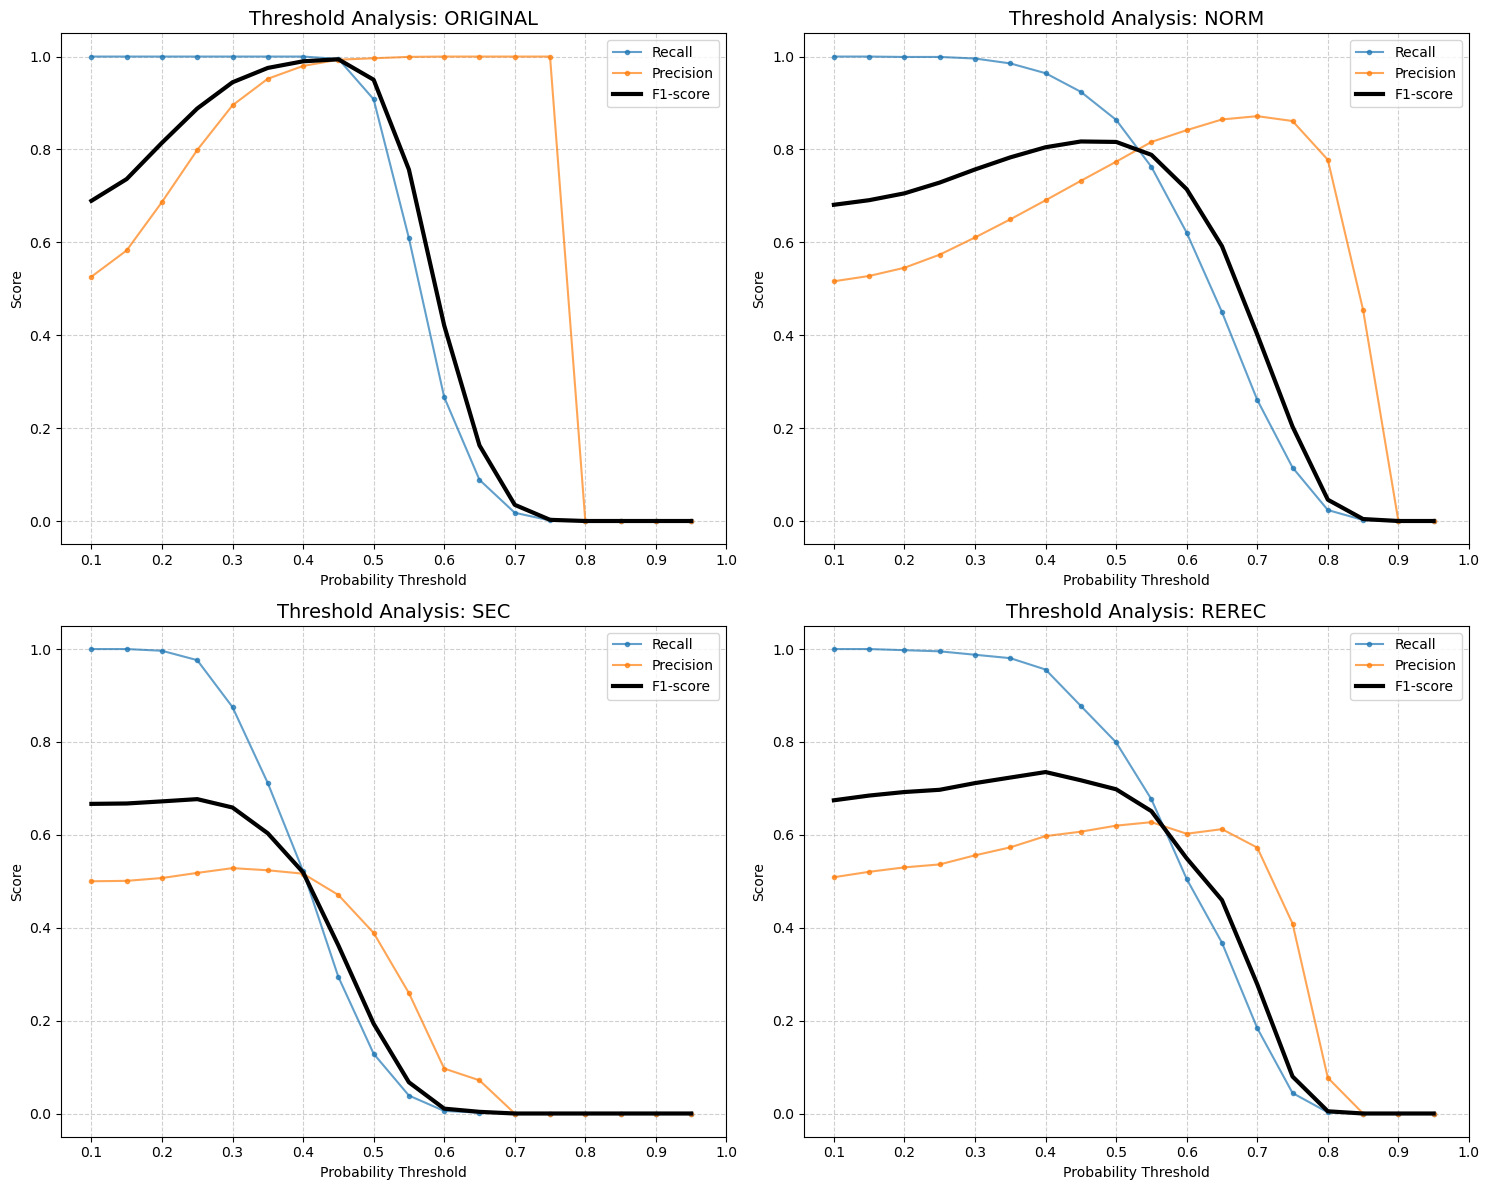

In [ ]:
final_metrics = []



thresholds = np.arange(0.1, 1, 0.05)

fig, axes = plt.subplots(2,2, figsize=(15,12))
axes = axes.ravel()

for i, (name, data) in enumerate(datasets.items()):

    X_train, y_train = data['train']
    X_test, y_test = data['test']
    
    
    params = rf_best_params[name] # Извлекаем параметры именно для этого датасета
    

    model = ensemble.RandomForestClassifier(**params, random_state=42, n_jobs=-1, max_features='sqrt')
    model.fit(X_train, y_train)
    
    
    # Предсказание
    y_pred = model.predict_proba(X_test)[:,1]
    y_score = pd.Series(y_pred)

    recall_scores = []
    precision_scores = []
    f1_scores = []

    for threshold in thresholds:
        # Если вероятность > threshold, то 1, иначе 0
        y_pred_custom = (y_score > threshold).astype(int)
        
        recall_scores.append(metrics.recall_score(y_test, y_pred_custom))
        precision_scores.append(metrics.precision_score(y_test, y_pred_custom))
        f1_scores.append(metrics.f1_score(y_test, y_pred_custom))

    # 5. Визуализация на i-м графике
    ax = axes[i]
    ax.plot(thresholds, recall_scores, label='Recall', marker='.', alpha=0.7)
    ax.plot(thresholds, precision_scores, label='Precision', marker='.', alpha=0.7)
    ax.plot(thresholds, f1_scores, label='F1-score', lw=3, color='black') # Выделим F1 пожирнее

    # Оформление графика
    ax.set_title(f'Threshold Analysis: {name.upper()}', fontsize=14)
    ax.set_xlabel('Probability Threshold')
    ax.set_ylabel('Score')
    ax.set_xticks(np.arange(0.1, 1.05, 0.1)) # Сетка чуть пореже для читаемости
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend()


plt.tight_layout()
plt.show()
    
    

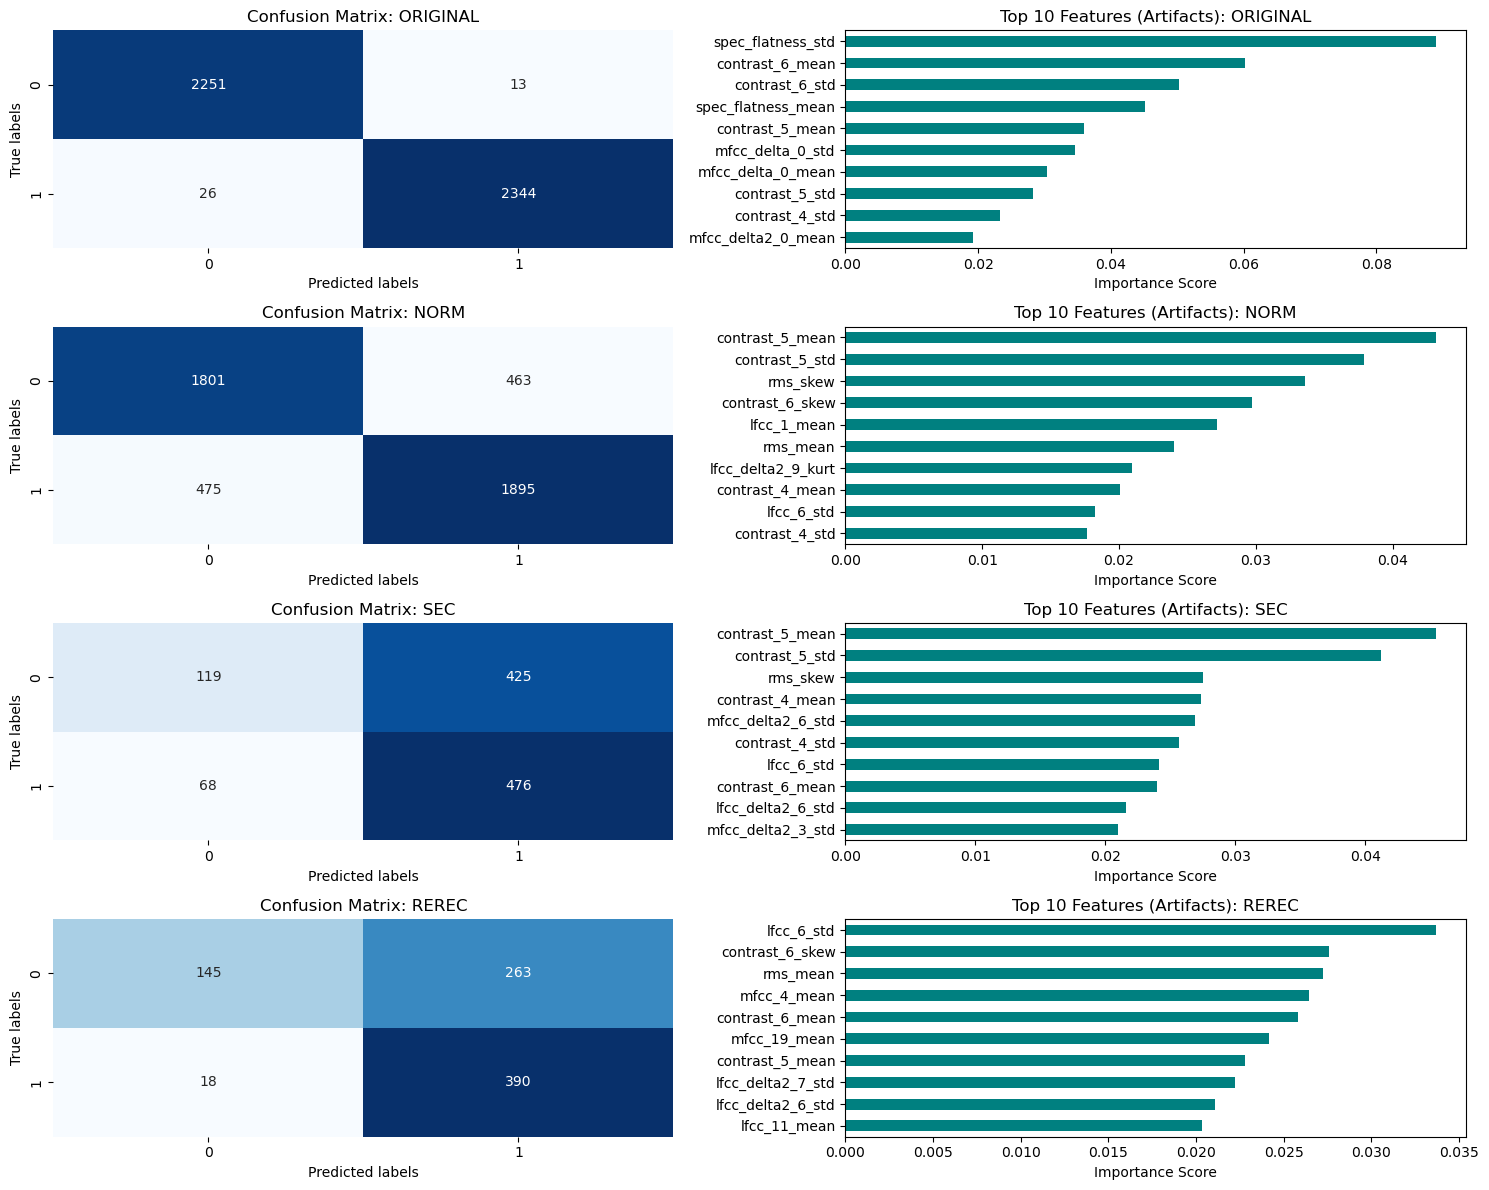


--- Итоговые результаты по всем датасетам ---
    Dataset       EER  Accuracy  F1-Score  Precision    Recall
0  original  0.007067  0.991584  0.991750   0.994485  0.989030
1      norm  0.204064  0.797583  0.801607   0.803647  0.799578
2       sec  0.485294  0.546875  0.658824   0.528302  0.875000
3     rerec  0.379902  0.655637  0.735156   0.597243  0.955882


In [33]:
final_metrics = []

custom_thresholds = {
      'original': 0.46,
      'norm': 0.535,
      'sec': 0.3,
      'rerec': 0.4, 
}

fig, axes = plt.subplots(4,2, figsize=(15,12))
#axes = axes.ravel()

for i, (name, data) in enumerate(datasets.items()):
    # Извлекаем данные
    X_train, y_train = data['train']
    X_test, y_test = data['test']
    
    # Извлекаем параметры именно для этого датасета
    params = rf_best_params[name]
    
    # Инициализация и обучение модели
    model = ensemble.RandomForestClassifier(**params, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    
    # Предсказание
    y_proba_pred = model.predict_proba(X_test)[:, 1]

    eer, _ = caluculate_eer(y_test, y_proba_pred)

    y_proba_pred = pd.Series(y_proba_pred)

    current_thresh = custom_thresholds[name]

    y_pred_opt = y_proba_pred.apply(lambda x: 1 if x > current_thresh else 0)
    
    # Расчет метрик
    acc = metrics.accuracy_score(y_test, y_pred_opt)
    f1 = metrics.f1_score(y_test, y_pred_opt)
    precision = metrics.precision_score(y_test, y_pred_opt)
    recall = metrics.recall_score(y_test, y_pred_opt)
    
    # Сохраняем метрики в список
    final_metrics.append({
        'Dataset': name,
        'EER': eer,
        'Accuracy': acc,
        'F1-Score': f1,
        'Precision': precision,
        'Recall': recall
    })
    
    # Визуализация Confusion Matrix
    cm = metrics.confusion_matrix(y_test, y_pred_opt)
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i, 0], cmap='Blues', cbar=False)
    axes[i, 0].set_title(f'Confusion Matrix: {name.upper()}')
    axes[i, 0].set_xlabel('Predicted labels')
    axes[i, 0].set_ylabel('True labels')

    importances = pd.Series(model.feature_importances_, index=X_train.columns)
    importances.nlargest(10).sort_values().plot(kind='barh', ax=axes[i, 1], color='teal')
    axes[i, 1].set_title(f"Top 10 Features (Artifacts): {name.upper()}", fontsize=12)
    axes[i, 1].set_xlabel('Importance Score')

# Корректировка расположения графиков
plt.tight_layout()
plt.show()

# # 4. Вывод итоговой сводной таблицы
df_results = pd.DataFrame(final_metrics)
# df_results.to_excel('results/research4_rf_result.xlsx')
print("\n--- Итоговые результаты по всем датасетам ---")
print(df_results)

## XGB

In [91]:
storage_xgb = 'sqlite:///XGB_research3.db'
summaries = optuna.get_all_study_summaries(storage=storage_xgb)

print("Реальные имена исследований в базе XGB:")
for s in summaries:
    print(f"- {s.study_name}")

Реальные имена исследований в базе XGB:
- xgb_original
- xgb_norm
- xgb_sec
- xgb_rerec


In [92]:
# xgb_best_params = {
#     'original': {
#         'n_estimators':  100,
#         'learning_rate': 0.03585767222177586,
#         'max_depth': 3,
#         'gamma': 0.000011436262417065974	,
#         'lambda': 4.4842691366626603e-7,
#         'alpha': 0.0000031341607416715898,
#         'subsample': 0.6640171770438117	,
#         'colsample_bytree': 0.7921209792331194,
#         'min_child_weight': 1,
#         'random_state': 42
#     },
#     'norm': {
#         'n_estimators':  445	,
#         'learning_rate': 0.05092025415930008,
#         'max_depth': 	5,
#         'gamma': 1.0336112686768962e-7,
#         'lambda': 0.00002739773652739808,
#         'alpha': 4.510817129530233e-7	,
#         'subsample': 0.7306973837340678,
#         'colsample_bytree': 0.9899933338933019,
#         'min_child_weight': 1,
#         'random_state': 42
#     },
#     '2sec': {
#         'n_estimators':  312,
#         'learning_rate': 0.0732603254242911,
#         'max_depth': 5,
#         'gamma': 2.4743823464976903e-7,
#         'lambda': 0.000003879738917184811,
#         'alpha': 0.000007257585790166375,
#         'subsample': 0.7634077600638957,
#         'colsample_bytree': 0.719876963342162,
#         'min_child_weight': 1,
#         'random_state': 42
#     },
#     'rerec': {
#         'n_estimators':  426,
#         'learning_rate': 0.07690895114239865,
#         'max_depth': 6,
#         'gamma': 1.0516757975009267e-8,
#         'lambda': 0.30677004804091457,
#         'alpha': 3.037453625202836e-7	,
#         'subsample': 0.6586328087671923,
#         'colsample_bytree': 0.9504762127836405,
#         'min_child_weight': 1,
#         'random_state': 42
#     },
# }

xgb_best_params = {}
datasets_names = ['original', 'norm', 'sec', 'rerec']

for name in datasets_names:
    study = optuna.load_study(study_name=f'xgb_{name}', storage='sqlite:///XGB_research3.db')
    xgb_best_params[name] = study.best_params

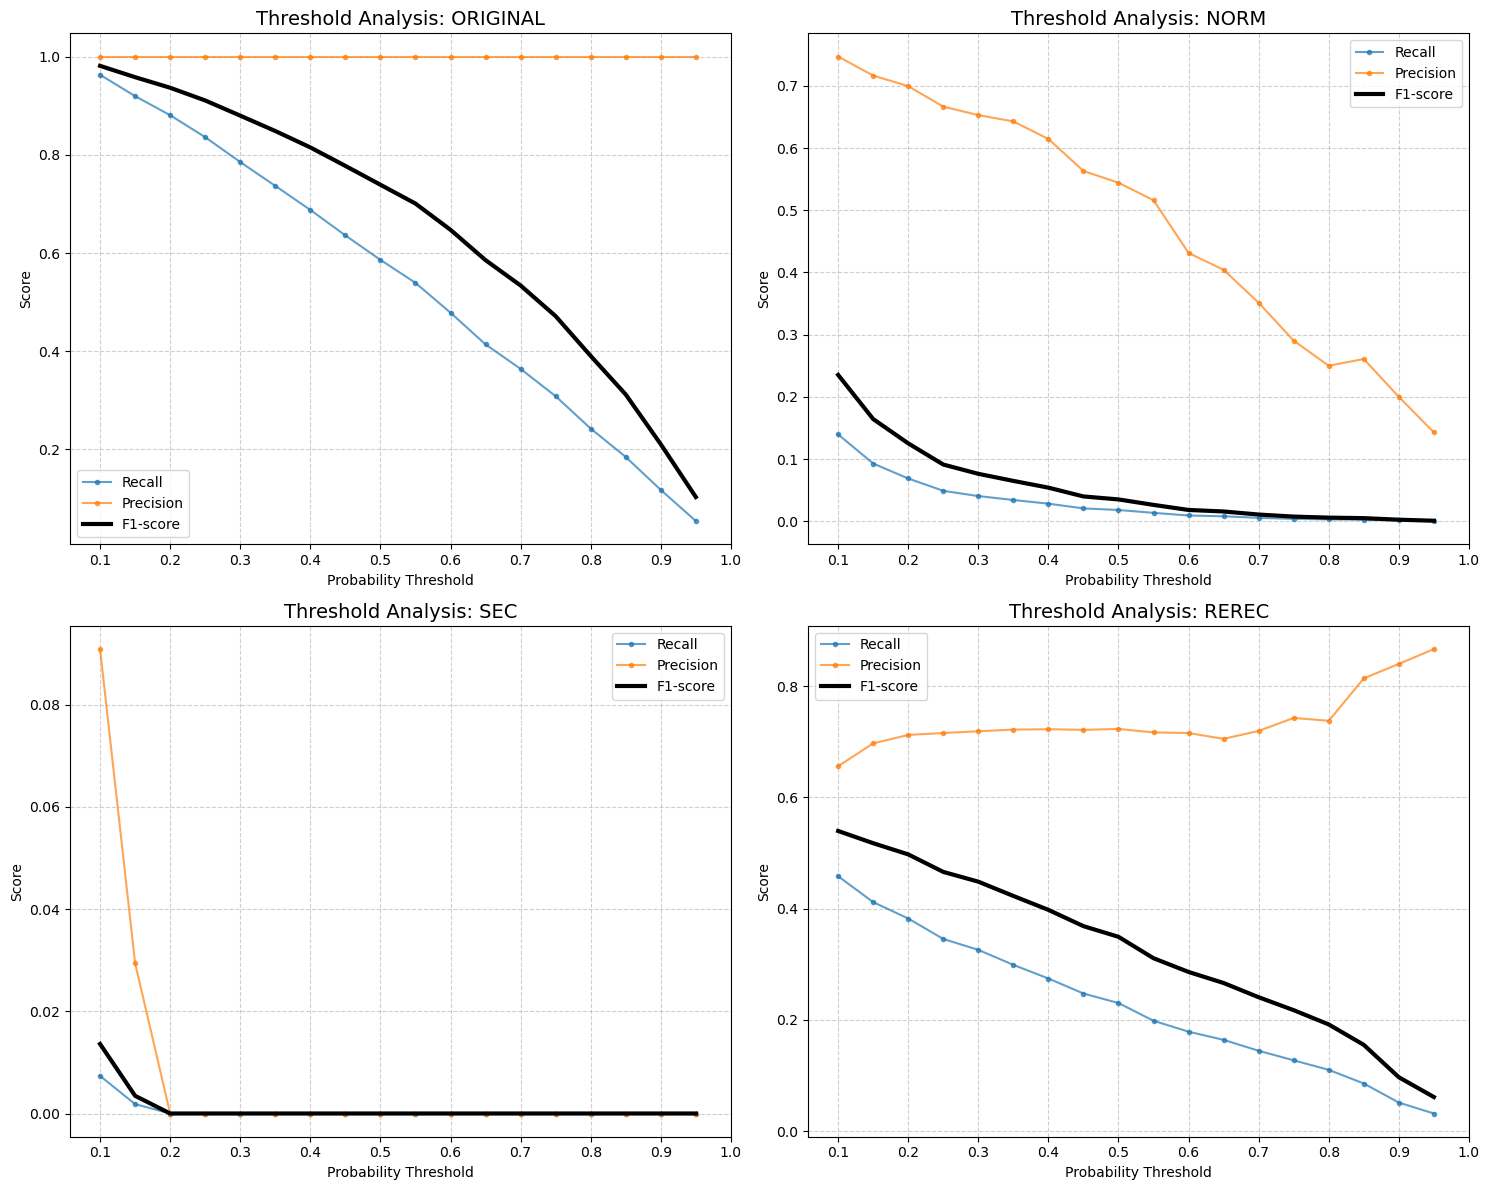

In [93]:
final_metrics = []



thresholds = np.arange(0.1, 1, 0.05)

fig, axes = plt.subplots(2,2, figsize=(15,12))
axes = axes.ravel()

for i, (name, data) in enumerate(datasets.items()):
    # Извлекаем данные
    X_train, y_train = data['train']
    X_test, y_test = data['test']
    
    # Извлекаем параметры именно для этого датасета
    params = xgb_best_params[name]
    
    # Инициализация и обучение модели
    model = xgb.XGBClassifier(**params)
    model.fit(X_train, y_train)
    
    # Предсказание
    y_pred = model.predict_proba(X_test)[:,1]
    y_score = pd.Series(y_pred)

    recall_scores = []
    precision_scores = []
    f1_scores = []

    for threshold in thresholds:
            # Если вероятность > threshold, то 1, иначе 0
            y_pred_custom = (y_score > threshold).astype(int)
            
            recall_scores.append(metrics.recall_score(y_test, y_pred_custom, zero_division=0))
            precision_scores.append(metrics.precision_score(y_test, y_pred_custom, zero_division=0))
            f1_scores.append(metrics.f1_score(y_test, y_pred_custom, zero_division=0))

    # 5. Визуализация на i-м графике
    ax = axes[i]
    ax.plot(thresholds, recall_scores, label='Recall', marker='.', alpha=0.7)
    ax.plot(thresholds, precision_scores, label='Precision', marker='.', alpha=0.7)
    ax.plot(thresholds, f1_scores, label='F1-score', lw=3, color='black') # Выделим F1 пожирнее

    # Оформление графика
    ax.set_title(f'Threshold Analysis: {name.upper()}', fontsize=14)
    ax.set_xlabel('Probability Threshold')
    ax.set_ylabel('Score')
    ax.set_xticks(np.arange(0.1, 1.05, 0.1)) # Сетка чуть пореже для читаемости
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend()


plt.tight_layout()
plt.show()

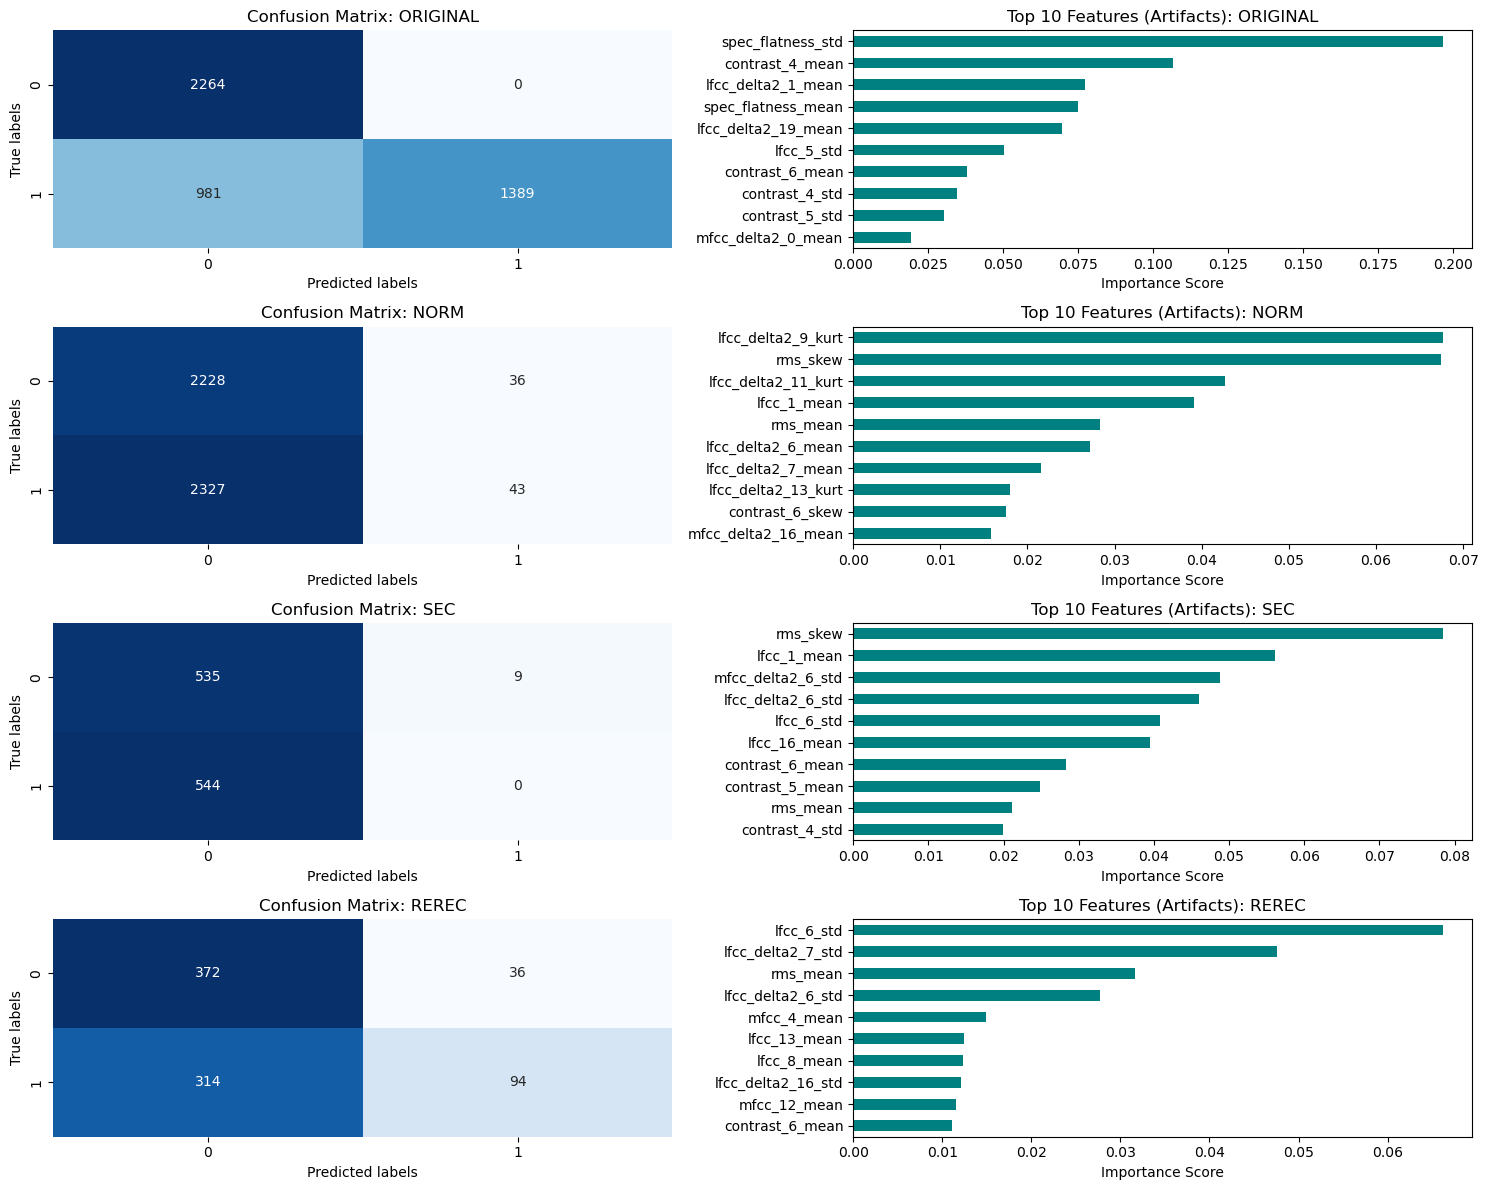


--- Итоговые результаты по всем датасетам ---
    Dataset       EER  Accuracy  F1-Score  Precision    Recall
0  original  0.000883  0.788304  0.739026   1.000000  0.586076
1      norm  0.246466  0.490073  0.035116   0.544304  0.018143
2       sec  0.558824  0.491728  0.000000   0.000000  0.000000
3     rerec  0.394608  0.571078  0.349442   0.723077  0.230392


In [121]:
final_metrics = []

custom_thresholds = {
      'original': 0.5,
      'norm': 0.5,
      'sec': 0.5,
      'rerec': 0.5, 
}

fig, axes = plt.subplots(4,2, figsize=(15,12))
#axes = axes.ravel()

for i, (name, data) in enumerate(datasets.items()):
    # Извлекаем данные
    X_train, y_train = data['train']
    X_test, y_test = data['test']
    
    # Извлекаем параметры именно для этого датасета
    params = xgb_best_params[name]
    
    # Инициализация и обучение модели
    model = xgb.XGBClassifier(**params)
    model.fit(X_train, y_train)
    
    # Предсказание
    y_proba_pred = model.predict_proba(X_test)[:, 1]

    eer, _ = caluculate_eer(y_test, y_proba_pred)

    y_proba_pred = pd.Series(y_proba_pred)

    current_thresh = custom_thresholds[name]

    y_pred_opt = y_proba_pred.apply(lambda x: 1 if x > current_thresh else 0)
    
    # Расчет метрик
    acc = metrics.accuracy_score(y_test, y_pred_opt)
    f1 = metrics.f1_score(y_test, y_pred_opt)
    precision = metrics.precision_score(y_test, y_pred_opt)
    recall = metrics.recall_score(y_test, y_pred_opt)
    
    # Сохраняем метрики в список
    final_metrics.append({
        'Dataset': name,
        'EER': eer,
        'Accuracy': acc,
        'F1-Score': f1,
        'Precision': precision,
        'Recall': recall
    })
    
    # Визуализация Confusion Matrix
    cm = metrics.confusion_matrix(y_test, y_pred_opt)
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i, 0], cmap='Blues', cbar=False)
    axes[i, 0].set_title(f'Confusion Matrix: {name.upper()}')
    axes[i, 0].set_xlabel('Predicted labels')
    axes[i, 0].set_ylabel('True labels')

    importances = pd.Series(model.feature_importances_, index=X_train.columns)
    importances.nlargest(10).sort_values().plot(kind='barh', ax=axes[i, 1], color='teal')
    axes[i, 1].set_title(f"Top 10 Features (Artifacts): {name.upper()}", fontsize=12)
    axes[i, 1].set_xlabel('Importance Score')

# Корректировка расположения графиков
plt.tight_layout()
plt.show()

# 4. Вывод итоговой сводной таблицы
df_results = pd.DataFrame(final_metrics)
df_results.to_excel('results/research4_xgb_result.xlsx')
print("\n--- Итоговые результаты по всем датасетам ---")
print(df_results)

## KNN

In [ ]:
knn_best_params = {
    'original': {
        'n_neighbors': 15,
        'weights': 'distance',
        'p':2,
    },
    'norm': {
        'n_neighbors': 7,
        'weights': 'uniform',
        'p': 1,
    },
    '2sec': {
        'n_neighbors': 11,
        'weights': 'uniform',
        'p': 1,
    },
    'rerec': {
        'n_neighbors': 11,
        'weights': 'uniform',
        'p': 1,
    },
}

# knn_best_params = {}
# datasets_names = ['original', 'norm', 'sec', 'rerec']

# for name in datasets_names:
#     study = optuna.load_study(study_name=f'knn_{name}', storage='sqlite:///knn_research3.db')
#     knn_best_params[name] = study.best_params

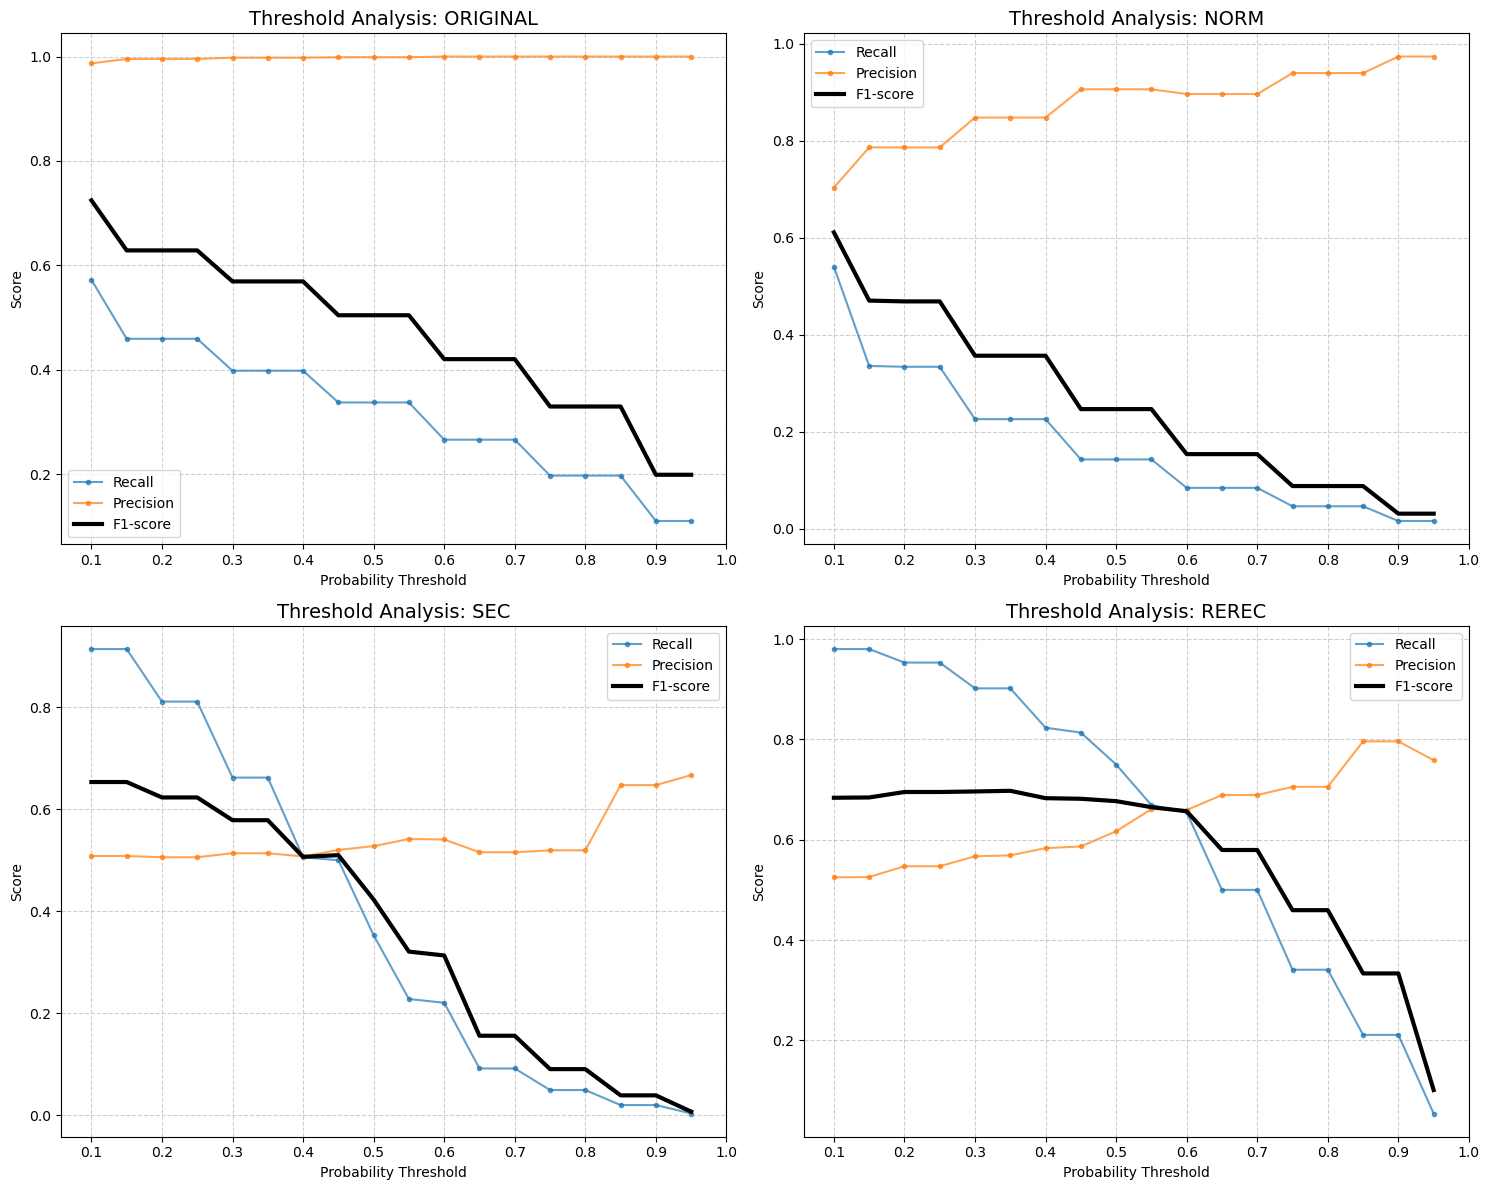

In [ ]:
final_metrics = []



thresholds = np.arange(0.1, 1, 0.05)

fig, axes = plt.subplots(2,2, figsize=(15,12))
axes = axes.ravel()

for i, (name, data) in enumerate(datasets.items()):
    # Извлекаем данные
    X_train, y_train = data['train']
    X_test, y_test = data['test']
    
    # Извлекаем параметры именно для этого датасета
    params = knn_best_params[name]
    
    # Инициализация и обучение модели
    model = neighbors.KNeighborsClassifier(**params, n_jobs=-1)
    model.fit(X_train, y_train)
    
    # Предсказание
    y_pred = model.predict_proba(X_test)[:,1]
    y_score = pd.Series(y_pred)

    recall_scores = []
    precision_scores = []
    f1_scores = []

    for threshold in thresholds:
            # Если вероятность > threshold, то 1, иначе 0
            y_pred_custom = (y_score > threshold).astype(int)
            
            recall_scores.append(metrics.recall_score(y_test, y_pred_custom))
            precision_scores.append(metrics.precision_score(y_test, y_pred_custom))
            f1_scores.append(metrics.f1_score(y_test, y_pred_custom))

    # 5. Визуализация на i-м графике
    ax = axes[i]
    ax.plot(thresholds, recall_scores, label='Recall', marker='.', alpha=0.7)
    ax.plot(thresholds, precision_scores, label='Precision', marker='.', alpha=0.7)
    ax.plot(thresholds, f1_scores, label='F1-score', lw=3, color='black') # Выделим F1 пожирнее

    # Оформление графика
    ax.set_title(f'Threshold Analysis: {name.upper()}', fontsize=14)
    ax.set_xlabel('Probability Threshold')
    ax.set_ylabel('Score')
    ax.set_xticks(np.arange(0.1, 1.05, 0.1)) # Сетка чуть пореже для читаемости
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend()


plt.tight_layout()
plt.show()

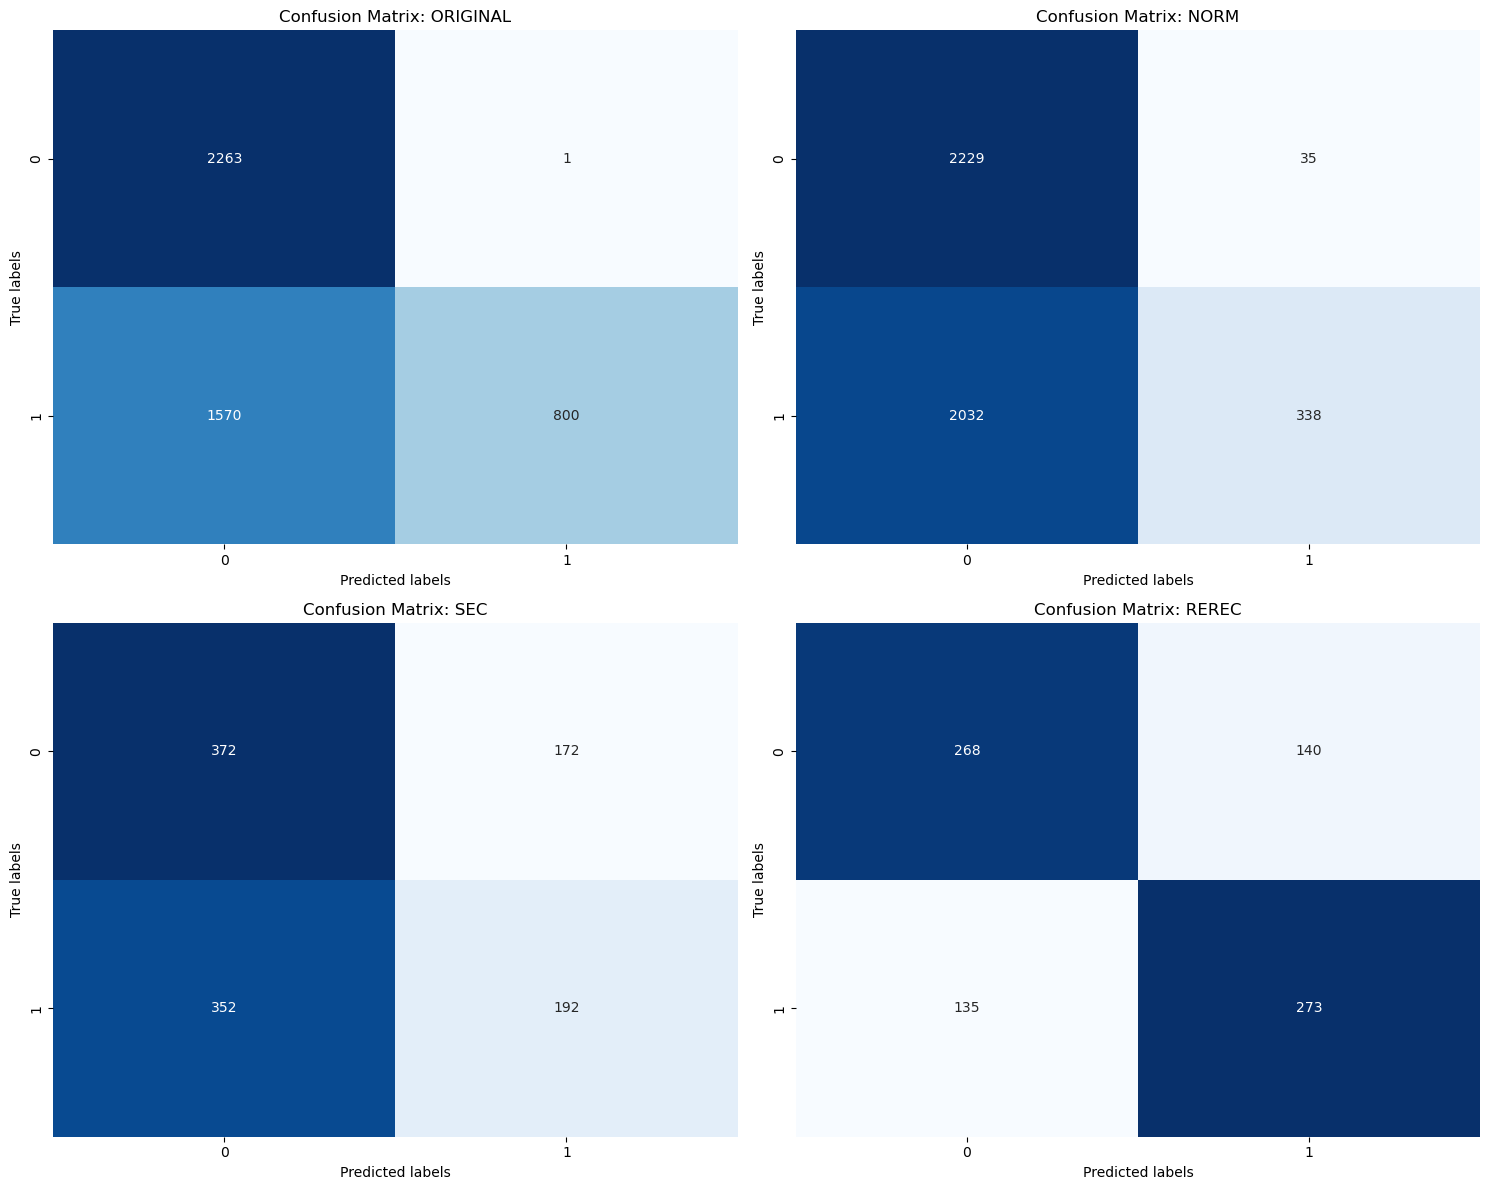


--- Итоговые результаты по всем датасетам ---
    Dataset       EER  Accuracy  F1-Score  Precision    Recall
0  original  0.301116  0.660984  0.504573   0.998752  0.337553
1      norm  0.386184  0.553949  0.246445   0.906166  0.142616
2       sec  0.492647  0.518382  0.422907   0.527473  0.352941
3     rerec  0.343137  0.662990  0.665043   0.661017  0.669118


In [122]:
final_metrics = []

custom_thresholds = {
      'original': 0.5,
      'norm': 0.55,
      'sec': 0.5,
      'rerec': 0.55, 
}

fig, axes = plt.subplots(2,2, figsize=(15,12))
axes = axes.ravel()

for i, (name, data) in enumerate(datasets.items()):
    # Извлекаем данные
    X_train, y_train = data['train']
    X_test, y_test = data['test']
    
    # Извлекаем параметры именно для этого датасета
    params = knn_best_params[name]
    
    # Инициализация и обучение модели
    model = neighbors.KNeighborsClassifier(**params, n_jobs=-1)
    model.fit(X_train, y_train)
    
    # Предсказание
    y_proba_pred = model.predict_proba(X_test)[:, 1]

    eer, _ = caluculate_eer(y_test, y_proba_pred)

    y_proba_pred = pd.Series(y_proba_pred)

    current_thresh = custom_thresholds[name]

    y_pred_opt = y_proba_pred.apply(lambda x: 1 if x > current_thresh else 0)
    
    # Расчет метрик
    acc = metrics.accuracy_score(y_test, y_pred_opt)
    f1 = metrics.f1_score(y_test, y_pred_opt)
    precision = metrics.precision_score(y_test, y_pred_opt)
    recall = metrics.recall_score(y_test, y_pred_opt)
    
    # Сохраняем метрики в список
    final_metrics.append({
        'Dataset': name,
        'EER': eer,
        'Accuracy': acc,
        'F1-Score': f1,
        'Precision': precision,
        'Recall': recall
    })
    
    # Визуализация Confusion Matrix
    cm = metrics.confusion_matrix(y_test, y_pred_opt)
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i], cmap='Blues', cbar=False)
    axes[i].set_title(f'Confusion Matrix: {name.upper()}')
    axes[i].set_xlabel('Predicted labels')
    axes[i].set_ylabel('True labels')

    

# Корректировка расположения графиков
plt.tight_layout()
plt.show()

# 4. Вывод итоговой сводной таблицы
df_results = pd.DataFrame(final_metrics)
df_results.to_excel('results/research4_knn_result.xlsx')
print("\n--- Итоговые результаты по всем датасетам ---")
print(df_results)